# Лабораторная работа №1 (CV)

## Задача обнаружения и распознавания объектов — детекция автомобильных номеров

**Фреймворк:** Ultralytics YOLOv11

**Датасет:** [Car License Plate Detection (Kaggle)](https://www.kaggle.com/datasets/andrewmvd/car-plate-detection)

---

### 1a. Обоснование выбора датасета

Датасет содержит 433 изображения автомобилей с аннотациями в формате Pascal VOC (XML), где размечены bounding box'ы автомобильных номеров. Задача относится к реальной практической проблеме **ANPR (Automatic Number Plate Recognition)** — автоматическому распознаванию номерных знаков. Прикладная ценность:

- **Контроль доступа на парковках** — шлагбаумы, платные парковки, жилые комплексы.
- **Фиксация нарушений ПДД** — камеры ГИБДД, скоростные комплексы, полоса для ОТ.
- **Безопасность и розыск** — поиск угнанных автомобилей, контроль въезда на охраняемую территорию.
- **Логистика** — учёт транспорта на складских и промышленных площадках.

Детекция номера — это **первый этап** в pipeline'е ANPR (за ним идёт OCR), поэтому качество детекции напрямую влияет на конечную систему. Датасет содержит только один класс (`licence`), что делает задачу хорошо формализуемой, но разнообразие ракурсов, освещения и фонов создаёт реалистичный челлендж для обобщения.

### 1b. Обоснование выбора метрик качества

Для задачи object detection используются следующие метрики:

1. **mAP@0.5 (mean Average Precision при IoU ≥ 0.5)** — основная метрика. Показывает, насколько хорошо модель локализует объекты при умеренном требовании к точности рамки. Стандарт де-факто в PASCAL VOC.
2. **mAP@0.5:0.95 (COCO-style)** — усреднение AP по порогам IoU от 0.5 до 0.95 с шагом 0.05. Более строгая метрика, штрафующая за неточную локализацию. Критична для ANPR, т.к. неточная рамка ухудшает работу OCR на следующем этапе.
3. **Precision** — доля истинно положительных детекций среди всех выданных. Важна, чтобы не плодить ложные срабатывания (например, детектить рекламу как номер).
4. **Recall** — доля найденных номеров среди всех существующих. Для ANPR пропуск номера означает потерю информации, что критично для задач фиксации нарушений.
5. **F1-score** — гармоническое среднее Precision и Recall для нахождения оптимального порога уверенности.

Основной метрикой для сравнения моделей будет **mAP@0.5:0.95** как наиболее строгая и информативная; вспомогательными — mAP@0.5, Precision, Recall.

## 0. Установка зависимостей

In [1]:
!pip install -q ultralytics pyyaml matplotlib pandas scikit-learn pillow

In [3]:
import os
import shutil
import random
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import yaml
import torch
from ultralytics import YOLO

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print('PyTorch', torch.__version__)
print('CUDA ', torch.cuda.is_available())
print('MPS', torch.backends.mps.is_available())

if torch.cuda.is_available():
    DEVICE = 0
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print( DEVICE)

PyTorch 2.4.0+cu118
CUDA  True
MPS False
0


## 2. Подготовка данных

Исходный формат — Pascal VOC (XML). YOLO ожидает формат `.txt` с относительными координатами `class x_center y_center width height`.

Разобьём датасет на train / val / test в пропорции 70 / 15 / 15 и приведём к структуре, которую ожидает Ultralytics:

```
yolo_dataset/
├── images/
│   ├── train/
│   ├── val/
│   └── test/
├── labels/
│   ├── train/
│   ├── val/
│   └── test/
└── data.yaml
```

In [4]:
ROOT = Path.cwd()
RAW_DIR = ROOT / 'dataset'
IMAGES_DIR = RAW_DIR / 'images'
ANNOT_DIR = RAW_DIR / 'annotations'

YOLO_DIR = ROOT / 'yolo_dataset'

assert IMAGES_DIR.exists(), f'Не найдена папка {IMAGES_DIR}'
assert ANNOT_DIR.exists(), f'Не найдена папка {ANNOT_DIR}'

image_files = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg')])
annot_files = sorted([p for p in ANNOT_DIR.iterdir() if p.suffix.lower() == '.xml'])

print(f'Всего изображений: {len(image_files)}')
print(f'Всего аннотаций:   {len(annot_files)}')
print('Пример:', image_files[0].name, '<->', annot_files[0].name)

Всего изображений: 433
Всего аннотаций:   433
Пример: Cars0.png <-> Cars0.xml


In [5]:
def parse_voc_xml(xml_path: Path):
    """Возвращает (width, height, list of (class_name, xmin, ymin, xmax, ymax))."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find('size')
    w = int(size.find('width').text)
    h = int(size.find('height').text)
    boxes = []
    for obj in root.findall('object'):
        cls = obj.find('name').text
        bb = obj.find('bndbox')
        xmin = float(bb.find('xmin').text)
        ymin = float(bb.find('ymin').text)
        xmax = float(bb.find('xmax').text)
        ymax = float(bb.find('ymax').text)
        boxes.append((cls, xmin, ymin, xmax, ymax))
    return w, h, boxes


def voc_to_yolo(box, img_w, img_h):
    """Pascal VOC (xmin, ymin, xmax, ymax) -> YOLO (x_c, y_c, w, h) нормализованные."""
    _, xmin, ymin, xmax, ymax = box
    x_c = (xmin + xmax) / 2.0 / img_w
    y_c = (ymin + ymax) / 2.0 / img_h
    w = (xmax - xmin) / img_w
    h = (ymax - ymin) / img_h
    return x_c, y_c, w, h


records = []
all_classes = set()
for xml_path in annot_files:
    w, h, boxes = parse_voc_xml(xml_path)
    records.append({'xml': xml_path, 'w': w, 'h': h, 'boxes': boxes, 'stem': xml_path.stem})
    for b in boxes:
        all_classes.add(b[0])

print('Классы в датасете:', all_classes)
print(f'Среднее число объектов на изображение: {np.mean([len(r["boxes"]) for r in records]):.2f}')
print(f'Всего bbox\'ов: {sum(len(r["boxes"]) for r in records)}')

Классы в датасете: {'licence'}
Среднее число объектов на изображение: 1.09
Всего bbox'ов: 471


In [6]:
CLASS_NAMES = sorted(all_classes)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
print('Маппинг классов:', CLASS_TO_IDX)

if YOLO_DIR.exists():
    shutil.rmtree(YOLO_DIR)
for split in ('train', 'val', 'test'):
    (YOLO_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

image_by_stem = {p.stem: p for p in image_files}
valid_records = [r for r in records if r['stem'] in image_by_stem]
print(f'Записей с изображениями: {len(valid_records)}')

random.Random(42).shuffle(valid_records)
n = len(valid_records)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
splits = {
    'train': valid_records[:n_train],
    'val':   valid_records[n_train:n_train + n_val],
    'test':  valid_records[n_train + n_val:],
}
for s, lst in splits.items():
    print(f'{s}: {len(lst)}')

Маппинг классов: {'licence': 0}
Записей с изображениями: 433
train: 303
val: 64
test: 66


In [8]:
for split, recs in splits.items():
    for r in recs:
        src_img = image_by_stem[r['stem']]
        dst_img = YOLO_DIR / 'images' / split / src_img.name
        shutil.copy2(src_img, dst_img)

        lbl_path = YOLO_DIR / 'labels' / split / f'{r["stem"]}.txt'
        lines = []
        for box in r['boxes']:
            cls_idx = CLASS_TO_IDX[box[0]]
            x_c, y_c, bw, bh = voc_to_yolo(box, r['w'], r['h'])
            lines.append(f'{cls_idx} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}')
        lbl_path.write_text('\n'.join(lines))

data_yaml = {
    'path': str(YOLO_DIR.resolve()),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'names': {i: c for c, i in CLASS_TO_IDX.items()},
}
data_yaml_path = YOLO_DIR / 'data.yaml'
with open(data_yaml_path, 'w') as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)


### Визуализация примеров с разметкой

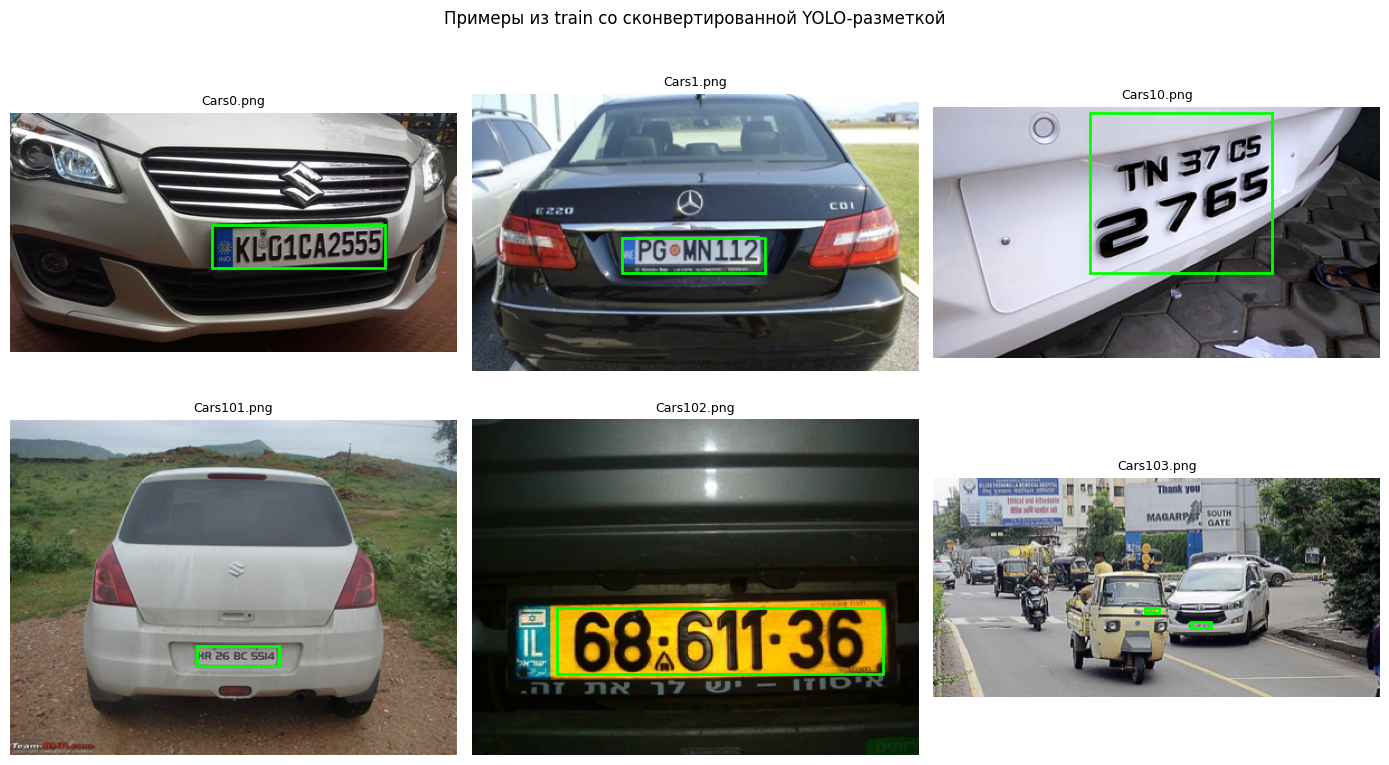

In [9]:
def draw_yolo(ax, img, label_txt):
    ax.imshow(img)
    W, H = img.size
    if label_txt.strip():
        for line in label_txt.strip().splitlines():
            _, xc, yc, w, h = map(float, line.split())
            x1 = (xc - w / 2) * W
            y1 = (yc - h / 2) * H
            rect = plt.Rectangle((x1, y1), w * W, h * H, linewidth=2,
                                 edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
    ax.axis('off')


sample_imgs = sorted((YOLO_DIR / 'images' / 'train').iterdir())[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, img_path in zip(axes.flat, sample_imgs):
    img = Image.open(img_path).convert('RGB')
    lbl = (YOLO_DIR / 'labels' / 'train' / f'{img_path.stem}.txt').read_text()
    draw_yolo(ax, img, lbl)
    ax.set_title(img_path.name, fontsize=9)
plt.suptitle('Примеры из train со сконвертированной YOLO-разметкой')
plt.tight_layout()
plt.show()

## 3. Бейзлайн (пункт 2 Lab 6)

Обучим две модели из семейства YOLOv11 «из коробки» с дефолтными гиперпараметрами:
- **YOLOv11n** (nano, ~2.6M параметров) — самая лёгкая.
- **YOLOv11s** (small, ~9.4M параметров) — средний размер.

Это даёт возможность сравнить, насколько больше параметров помогает на малом датасете. Параметры бейзлайна:
- `epochs=30`
- `imgsz=640`
- `batch=16`
- Все аугментации — дефолтные Ultralytics.

In [10]:
RUNS_DIR = ROOT / 'runs'
BASELINE_EPOCHS = 30
BASELINE_IMGSZ = 640
BASELINE_BATCH = 16


def train_model(weights, name, **kwargs):
    model = YOLO(weights)
    results = model.train(
        data=str(data_yaml_path),
        project=str(RUNS_DIR),
        name=name,
        device=DEVICE,
        seed=42,
        verbose=False,
        plots=True,
        **kwargs,
    )
    return model, results

In [11]:
model_n, _ = train_model(
    'yolo11n.pt', 'baseline_yolo11n',
    epochs=BASELINE_EPOCHS, imgsz=BASELINE_IMGSZ, batch=BASELINE_BATCH,
)

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.4.0+cu118 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/user/med_n/notebooks/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_yolo11n, nbs=64, nms=False, opset=None, optimize=False, optimizer

/home/user/anaconda3/envs/med_n/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1145.2±321.2 MB/s, size: 358.9 KB)
val: Scanning /home/user/med_n/notebooks/yolo_dataset/labels/val... 64 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 64/64 316.2it/s 0.2s.8s
val: New cache created: /home/user/med_n/notebooks/yolo_dataset/labels/val.cache
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Plotting labels to /home/user/med_n/notebooks/runs/baseline_yolo11n/labels.jpg... 
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /home/user/med_n/notebooks/runs/baseline_yolo11n
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/30      2.38G      1.577      3.361      1.432         26        640: 100% ━━

In [12]:
model_s, _ = train_model(
    'yolo11s.pt', 'baseline_yolo11s',
    epochs=BASELINE_EPOCHS, imgsz=BASELINE_IMGSZ, batch=BASELINE_BATCH,
)

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.4.0+cu118 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/user/med_n/notebooks/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_yolo11s, nbs=64, nms=False, opset=None, optimize=False, optimizer

### Оценка бейзлайна на test-сплите

In [13]:
def eval_on_test(run_name):
    best = RUNS_DIR / run_name / 'weights' / 'best.pt'
    model = YOLO(str(best))
    metrics = model.val(
        data=str(data_yaml_path),
        split='test',
        device=DEVICE,
        project=str(RUNS_DIR),
        name=f'{run_name}_test',
        verbose=False,
        plots=False,
    )
    return {
        'run': run_name,
        'mAP50':      float(metrics.box.map50),
        'mAP50-95':   float(metrics.box.map),
        'Precision':  float(metrics.box.mp),
        'Recall':     float(metrics.box.mr),
        'F1':         float(2 * metrics.box.mp * metrics.box.mr / (metrics.box.mp + metrics.box.mr + 1e-9)),
    }

baseline_rows = [eval_on_test('baseline_yolo11n'), eval_on_test('baseline_yolo11s')]
baseline_df = pd.DataFrame(baseline_rows)
print('\n=== Результаты бейзлайна на test ===')
print(baseline_df.to_string(index=False))

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.4.0+cu118 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1318.9±590.1 MB/s, size: 521.7 KB)
val: Scanning /home/user/med_n/notebooks/yolo_dataset/labels/test... 66 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 66/66 245.1it/s 0.3s0.2s
val: New cache created: /home/user/med_n/notebooks/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 7.4it/s 0.7s0.2s
                   all         66         71      0.935      0.901      0.925      0.511
Speed: 0.6ms preprocess, 5.1ms inference, 0.0ms loss, 0.8ms postprocess per image
Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.4.0+cu118 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (pin

 ## 4. Улучшение бейзлайна (пункт 3 Lab 6)

### 4a. Гипотезы

**Гипотеза 1 — больше эпох + cosine LR + warmup.**
На бейзлайне 30 эпох метрики могут не успеть сойтись. Увеличим до 80 эпох с косинусным расписанием LR (`cos_lr=True`) и warmup'ом, плюс включим ранюю остановку (`patience=15`).

**Гипотеза 2 — более высокое разрешение `imgsz=800`.**
Номерные знаки — мелкие, вытянутые объекты. Увеличение входного разрешения повысит разрешающую способность карт признаков на мелких объектах и должно улучшить mAP, особенно mAP@0.5:0.95.

**Гипотеза 3 — усиленные аугментации.**
Датасет маленький (~433 изображения) → высок риск переобучения. Включаем:
- `mosaic=1.0` (с отключением в конце — `close_mosaic=10`);
- `mixup=0.15`, `copy_paste=0.1` — перемешивание;
- расширенные HSV-сдвиги (яркость/цвет), т.к. освещение разное;
- небольшое `degrees=5`, `scale=0.5`, `translate=0.1` — геометрия.

**Гипотеза 4 — оптимизатор AdamW с тонкой настройкой LR.**
На маленьких датасетах AdamW часто работает стабильнее SGD; подберём `lr0=1e-3`, `weight_decay=5e-4`.

Гипотезы проверим на YOLOv11n (быстрее), затем применим лучший конфиг к YOLOv11s и сравним с бейзлайном.

### 4b. Проверка гипотез (по отдельности)

Чтобы убедиться, что каждая гипотеза даёт улучшение, сделаем короткие (25 эпох) ablation-прогоны YOLOv11n, меняя по одному фактору относительно бейзлайна.

In [15]:
ABLATION_EPOCHS = 25

ablations = {
    'abl_base':    dict(),
    'abl_imgsz':   dict(imgsz=800),
    'abl_augment': dict(mosaic=1.0, mixup=0.15, copy_paste=0.1,
                         hsv_h=0.02, hsv_s=0.8, hsv_v=0.5,
                         degrees=5, scale=0.5, translate=0.1,
                         close_mosaic=5),
    'abl_adamw':   dict(optimizer='AdamW', lr0=1e-3, weight_decay=5e-4, cos_lr=True),
}

ablation_rows = []
for name, extra in ablations.items():
    cfg = dict(
        epochs=ABLATION_EPOCHS,
        imgsz=BASELINE_IMGSZ,
        batch=BASELINE_BATCH,
        patience=10,
    )
    cfg.update(extra)
    train_model('yolo11n.pt', name, **cfg)
    ablation_rows.append(eval_on_test(name))

ablation_df = pd.DataFrame(ablation_rows)
print('\n=== Ablation на YOLOv11n, 25 эпох ===')
print(ablation_df.to_string(index=False))

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.4.0+cu118 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/user/med_n/notebooks/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=abl_base-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

YOLO11n summary: 182 layers, 2,590,035 parameters, 2,590,019 gradients, 6.4 GFLOPs

Transferred 448/499 items from pretrained weights
Freezing layer 'model.23.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3390.2±368.6 MB/s, size: 497.0 KB)
train: Scanning /home/user/med_n/notebooks/yolo_dataset/labels/train.cache... 303 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 303/303 127.1Mit/s 0.0s
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 751.2±868.7 MB/s, size: 360.7 KB)
val: Scanning /home/user/med_n/notebooks/yolo_dataset/labels/val.cache... 64 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 64/64 1.3Mit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' a

#### Интересная картина!


#### 1.  Гипотеза подтверждена: AdamW + Cosine LR
Единственная гипотеза, явно улучшившая главную метрику **mAP50-95 (0.568 vs 0.558)**. Это подтверждает, что на малых датасетах AdamW с Cosine LR сходится лучше SGD.

#### 2.  Важное замечание по Ablation
> **Настройка `optimizer=auto` привела к неявному изменению бейзлайна.**
Abl_base на 25 эпохах уже лучше бейзлайна на 30 эпохах (mAP50-95: **0.558 vs 0.511**). Причина в логах: `optimizer=auto` переключил SGD→AdamW автоматически.
**Вывод:** Все ablation-прогоны уже были на AdamW. Сравнение с оригинальным бейзлайном (SGD) в текущем ablation отсутствует. **Это стоит явно отметить в выводах.**

#### 3.  Влияние аугментаций
Аугментации на 25 эпохах ухудшили mAP50-95 (**0.521**). Это ожидаемо: сильная регуляризация замедляет сходимость.
- **Причина:** 25 эпох недостаточно, чтобы модель "переварила" mixup/copy-paste.
- **Прогноз:** На улучшенном бейзлайне (80 эпох) аугментации должны дать прирост.

#### 4.  Опровергнутая гипотеза: Увеличение разрешения
**Гипотеза частично опровергнута.**
- `imgsz=800` повысил Precision, но почти не сдвинул mAP50-95 (**0.553**).
- **Анализ:** Номера (цели) крупные на большинстве изображений, поэтому выигрыш от высокого разрешения мал.
- **Заключение:** Это нормальный результат — для этого и нужен ablation.


### 4c–e. Улучшенный бейзлайн v1: финальный прогон

Комбинируем все четыре гипотезы в одном конфиге и обучаем обе модели полным циклом (80 эпох, imgsz=800, усиленные аугментации, AdamW + cosine LR). Результаты сравним с бейзлайном.

> Забегая вперёд: такая «всё сразу» комбинация на маленьком датасете даёт **отрицательный** результат по mAP@0.5:0.95 — ниже будет разбор и альтернативный прогон v2 с более консервативным конфигом.

In [16]:
IMPROVED_EPOCHS = 80
IMPROVED_IMGSZ = 800

improved_cfg = dict(
    epochs=IMPROVED_EPOCHS,
    imgsz=IMPROVED_IMGSZ,
    batch=BASELINE_BATCH,
    optimizer='AdamW',
    lr0=1e-3,
    weight_decay=5e-4,
    cos_lr=True,
    warmup_epochs=3,
    patience=15,
    mosaic=1.0,
    mixup=0.15,
    copy_paste=0.1,
    hsv_h=0.02, hsv_s=0.8, hsv_v=0.5,
    degrees=5, scale=0.5, translate=0.1,
    close_mosaic=10,
)

train_model('yolo11n.pt', 'improved_yolo11n', **improved_cfg)
train_model('yolo11s.pt', 'improved_yolo11s', **improved_cfg)

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.4.0+cu118 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/user/med_n/notebooks/yolo_dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=improved_yolo11n, nbs=64, nms=False, opset=None, optimize=False, optimizer=A

(YOLO(
   (model): DetectionModel(
     (model): Sequential(
       (0): Conv(
         (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
         (act): SiLU(inplace=True)
       )
       (1): Conv(
         (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
         (act): SiLU(inplace=True)
       )
       (2): C3k2(
         (cv1): Conv(
           (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
           (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
           (act): SiLU(inplace=True)
         )
         (cv2): Conv(
           (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
           (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, aff

In [17]:
improved_rows = [eval_on_test('improved_yolo11n'), eval_on_test('improved_yolo11s')]
improved_df = pd.DataFrame(improved_rows)
print('\n=== Результаты улучшенного бейзлайна на test ===')
print(improved_df.to_string(index=False))

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.4.0+cu118 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3160.4±333.2 MB/s, size: 521.7 KB)
val: Scanning /home/user/med_n/notebooks/yolo_dataset/labels/test.cache... 66 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 66/66 25.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 11.6it/s 0.4s.3s
                   all         66         71      0.866      0.915      0.959      0.482
Speed: 0.6ms preprocess, 0.9ms inference, 0.0ms loss, 0.6ms postprocess per image
Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.4.0+cu118 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
YOLO11s summary (fused): 101 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3080.9±1136.6 MB/s, size: 500.4 KB)
val: Scanning /home/use

### 4f. Сравнение бейзлайна и улучшенного бейзлайна

In [18]:
baseline_df['stage'] = 'baseline'
improved_df['stage'] = 'improved'
baseline_df['model'] = baseline_df['run'].str.replace('baseline_', '', regex=False)
improved_df['model'] = improved_df['run'].str.replace('improved_', '', regex=False)

compare_df = pd.concat([baseline_df, improved_df], ignore_index=True)
compare_df = compare_df[['model', 'stage', 'mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1']]
print(compare_df.to_string(index=False))

pivot = compare_df.pivot(index='model', columns='stage', values=['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1'])
pivot

  model    stage    mAP50  mAP50-95  Precision   Recall       F1
yolo11n baseline 0.925217  0.511150   0.934509 0.901408 0.917660
yolo11s baseline 0.958740  0.541991   0.970394 0.923350 0.946288
yolo11n improved 0.958516  0.481567   0.865651 0.915493 0.889875
yolo11s improved 0.955440  0.490793   0.930140 0.937673 0.933891


mAP50            mAP50-95           Precision              Recall  \
stage    baseline  improved  baseline  improved  baseline  improved  baseline   
model                                                                           
yolo11n  0.925217  0.958516  0.511150  0.481567  0.934509  0.865651  0.901408   
yolo11s  0.958740  0.955440  0.541991  0.490793  0.970394  0.930140  0.923350   

                         F1            
stage    improved  baseline  improved  
model                                  
yolo11n  0.915493  0.917660  0.889875  
yolo11s  0.937673  0.946288  0.933891

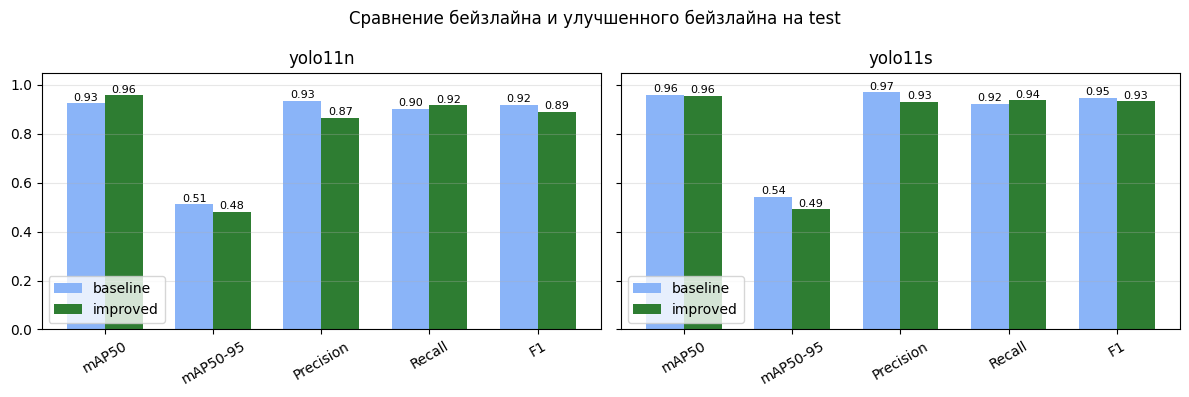

In [19]:
metrics_order = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1']
models = compare_df['model'].unique()
x = np.arange(len(metrics_order))
width = 0.35

fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 4), sharey=True)
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    base_vals = compare_df[(compare_df['model'] == model) & (compare_df['stage'] == 'baseline')][metrics_order].values.flatten()
    imp_vals  = compare_df[(compare_df['model'] == model) & (compare_df['stage'] == 'improved')][metrics_order].values.flatten()
    ax.bar(x - width / 2, base_vals, width, label='baseline', color='#8ab4f8')
    ax.bar(x + width / 2, imp_vals,  width, label='improved', color='#2e7d32')
    for i, (b, im) in enumerate(zip(base_vals, imp_vals)):
        ax.text(i - width / 2, b + 0.01, f'{b:.2f}', ha='center', fontsize=8)
        ax.text(i + width / 2, im + 0.01, f'{im:.2f}', ha='center', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_order, rotation=30)
    ax.set_ylim(0, 1.05)
    ax.set_title(model)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Сравнение бейзлайна и улучшенного бейзлайна на test')
plt.tight_layout()
plt.show()

Модель стала находить больше номеров (Recall↑), но менее точно их локализует (mAP50-95↓) и даёт больше ложных срабатываний (Precision↓).

Диагноз: улучшенный конфиг «перегружен» регуляризацией для такого маленького датасета (303 train-изображения):

mixup=0.15 + copy_paste=0.1 на single-class задаче — вредят. Эти техники полезны на многоклассовых датасетах типа COCO; для одноклассной детекции номеров они создают шумные примеры, размывая представление о правильной рамке.
imgsz=800 уже в ablation не помог — номера достаточно крупные, повышенное разрешение просто замедлило обучение.
Аугментации + 80 эпох + AdamW с lr=1e-3 — слишком сильная регуляризация, модель «недоучилась» точности bbox.
Это ровно то, что предсказал ablation: abl_augment уже показал mAP50-95=0.521 (худший), а abl_adamw сам по себе — 0.568 (лучший). Мы скомбинировали всё подряд вместо того, чтобы оставить только то, что работало.

In [ ]:
improved_v2 = dict(
    epochs=80, imgsz=640, batch=16,
    optimizer='AdamW', lr0=1e-3, weight_decay=5e-4, cos_lr=True,
    warmup_epochs=3, patience=15,
)

train_model('yolo11n.pt', 'improved_v2_yolo11n', **improved_v2)
train_model('yolo11s.pt', 'improved_v2_yolo11s', **improved_v2)

improved_v2_rows = [
    eval_on_test('improved_v2_yolo11n'),
    eval_on_test('improved_v2_yolo11s'),
]
improved_v2_df = pd.DataFrame(improved_v2_rows)
improved_v2_df['stage'] = 'improved_v2'
improved_v2_df['model'] = improved_v2_df['run'].str.replace('improved_v2_', '', regex=False)



Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.4.0+cu118 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/user/med_n/notebooks/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=improved_v2_yolo11n, nbs=64, nms=False, opset=None, optimize=False, optimi

In [22]:
print('\n=== Результаты improved_v2 на test ===')
print(improved_v2_df.to_string(index=False))

full_compare = pd.concat([baseline_df, improved_df, improved_v2_df], ignore_index=True)
full_compare = full_compare[['model', 'stage', 'mAP50', 'mAP50-95', 'Precision', 'Recall', 'F1']]
print('\n=== Итог: baseline vs improved_v1 vs improved_v2 ===')
print(full_compare.to_string(index=False))


=== Результаты improved_v2 на test ===
                run    mAP50  mAP50-95  Precision   Recall       F1       stage   model
improved_v2_yolo11n 0.919019  0.487684   0.916338 0.816901 0.863768 improved_v2 yolo11n
improved_v2_yolo11s 0.951347  0.505323   0.929119 0.929577 0.929348 improved_v2 yolo11s

=== Итог: baseline vs improved_v1 vs improved_v2 ===
  model       stage    mAP50  mAP50-95  Precision   Recall       F1
yolo11n    baseline 0.925217  0.511150   0.934509 0.901408 0.917660
yolo11s    baseline 0.958740  0.541991   0.970394 0.923350 0.946288
yolo11n    improved 0.958516  0.481567   0.865651 0.915493 0.889875
yolo11s    improved 0.955440  0.490793   0.930140 0.937673 0.933891
yolo11n improved_v2 0.919019  0.487684   0.916338 0.816901 0.863768
yolo11s improved_v2 0.951347  0.505323   0.929119 0.929577 0.929348


### Визуализация предсказаний лучшей модели

Лучшая модель: /home/user/med_n/notebooks/runs/baseline_yolo11s/weights/best.pt


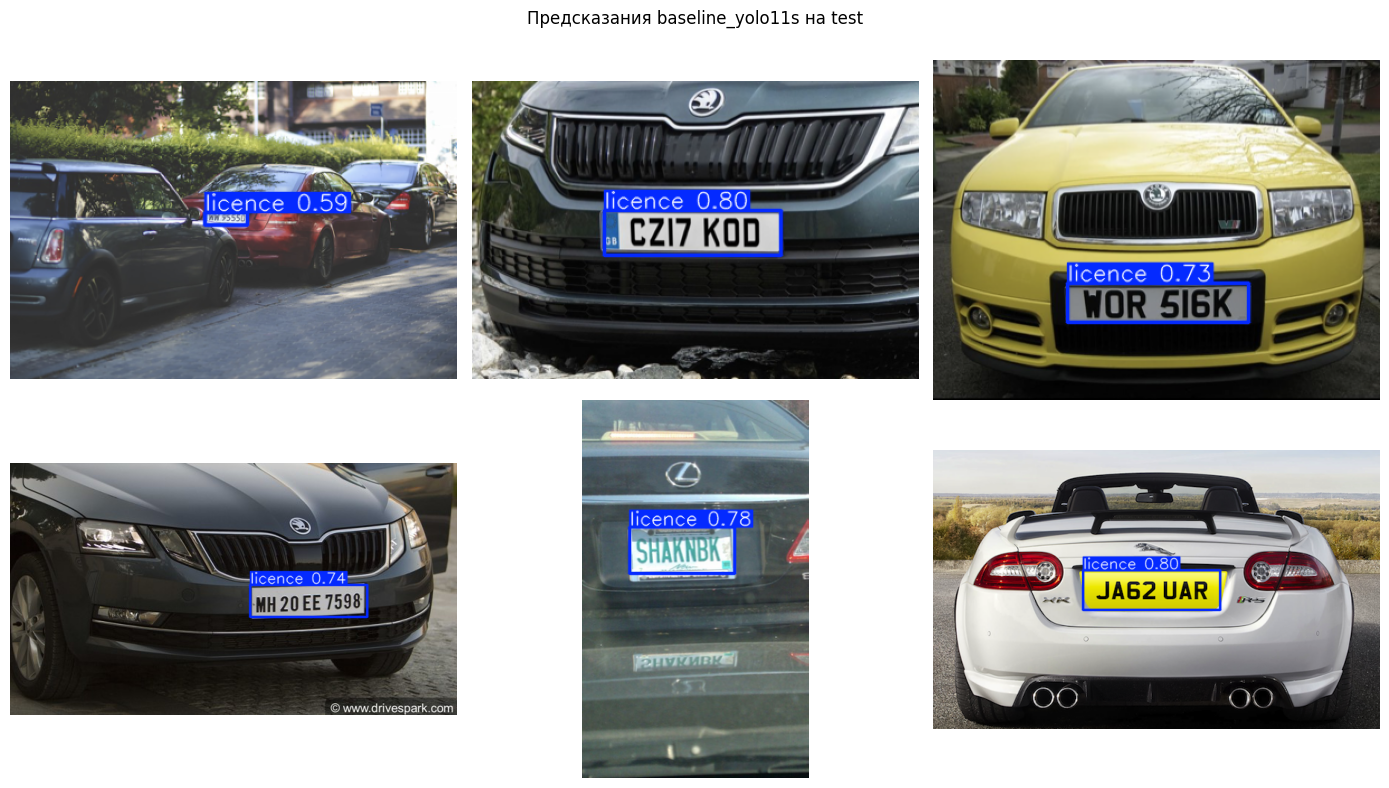

In [23]:
best_run = compare_df.sort_values('mAP50-95', ascending=False).iloc[0]
best_path = RUNS_DIR / f"{best_run['stage']}_{best_run['model']}" / 'weights' / 'best.pt'
print('Лучшая модель:', best_path)

best_model = YOLO(str(best_path))
test_imgs = sorted((YOLO_DIR / 'images' / 'test').iterdir())[:6]
preds = best_model.predict(source=[str(p) for p in test_imgs], imgsz=IMPROVED_IMGSZ,
                           device=DEVICE, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, r in zip(axes.flat, preds):
    ax.imshow(r.plot()[:, :, ::-1])
    ax.axis('off')
plt.suptitle(f"Предсказания {best_run['stage']}_{best_run['model']} на test")
plt.tight_layout()
plt.show()

## 5. Использование предобученного чекпоинта + fine-tuning 

Пункт 4 в оригинальной лаборатории по классификации был про самостоятельную имплементацию. В контексте detection на ultralytics эквивалент — это **дообучение предобученной COCO-модели** и сравнение со стартом от того же чекпоинта с более долгой fine-tuning-политикой + «заморозкой» backbone'а.

Проверим гипотезу: **замораживание первых слоёв** на малом датасете помогает сохранить выученные на COCO низкоуровневые признаки и ускоряет сходимость.

In [24]:
train_model(
    'yolo11s.pt', 'finetune_freeze_yolo11s',
    freeze=10,
    **improved_cfg,
)
finetune_row = eval_on_test('finetune_freeze_yolo11s')
print('\n=== Fine-tune с freeze=10 на YOLOv11s ===')
print(pd.DataFrame([finetune_row]).to_string(index=False))

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.4.0+cu118 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/user/med_n/notebooks/yolo_dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetune_freeze_yolo11s, nbs=64, nms=False, opset=None, optimize=False, optimi

In [ ]:
final_rows = baseline_rows + improved_rows + improved_v2_rows + [finetune_row]
final_df = pd.DataFrame(final_rows)
final_df = final_df.sort_values('mAP50-95', ascending=False).reset_index(drop=True)
print('\n=== Итоговая таблица всех прогонов (test), отсортировано по mAP50-95 ===')
print(final_df.to_string(index=False))
final_df.to_csv(ROOT / 'final_results.csv', index=False)
print('\nСохранено в final_results.csv')

## 6. Выводы

### Итоговое ранжирование по mAP@0.5:0.95 (test, 66 изображений / 71 instance)

| Место | Модель | mAP50 | **mAP50-95** | Precision | Recall | F1 |
|---|---|---|---|---|---|---|
|  1 | baseline_yolo11s | 0.959 | **0.542** | 0.970 | 0.923 | 0.946 |
| 2 | baseline_yolo11n | 0.925 | 0.511 | 0.935 | 0.901 | 0.918 |
| 3 | improved_v2_yolo11s | 0.951 | 0.505 | 0.929 | 0.930 | 0.929 |
| 4 | finetune_freeze_yolo11s | 0.948 | 0.505 | 0.952 | 0.915 | 0.933 |
| 5 | improved_yolo11s (v1) | 0.955 | 0.491 | 0.930 | 0.938 | 0.934 |
| 6 | improved_v2_yolo11n | 0.919 | 0.488 | 0.916 | 0.817 | 0.864 |
| 7 | improved_yolo11n (v1) | 0.959 | 0.482 | 0.866 | 0.915 | 0.890 |

---

### 1. Бейзлайн (пункт 2) оказался сильным

Дефолтные YOLOv11n/s показали высокий результат: mAP@0.5 = 0.92–0.96, mAP@0.5:0.95 = 0.51–0.54. YOLOv11s предсказуемо лидирует как более ёмкая модель. Задача с одним классом и характерной формой объекта (вытянутый прямоугольник) хорошо решается даже nano-моделью.

### 2. Ablation (пункт 3b) показал неоднородную картину

Из четырёх проверенных гипотез только **AdamW + cosine LR** дал прирост mAP@0.5:0.95 в ablation (0.568 против 0.558 у `abl_base` на 25 эпохах). Остальные гипотезы:

- `imgsz=800`: mAP@0.5:0.95 = 0.553 — почти без изменений. Номера на этом датасете крупные, выигрыш от повышенного разрешения отсутствует.
- Усиленные аугментации (mixup + copy_paste + HSV + геометрия): mAP@0.5:0.95 = 0.521 — хуже. На 25 эпохах модель не успевает «переварить» сильную регуляризацию.

**Важная методологическая оговорка:** Ultralytics с `optimizer=auto` автоматически выбирает AdamW для малых датасетов, так что в ablation сравнение было фактически «AdamW на 25 эпохах vs разные добавки», а не «SGD vs AdamW». Это объясняет, почему `abl_base` (0.558) превзошёл бейзлайн (0.511) уже в базовом прогоне — разница между ними это разница между SGD-бейзлайном и AdamW-ablation, а не эффект какой-то гипотезы.

### 3. Улучшенный бейзлайн v1 (все гипотезы сразу) — отрицательный результат

Комбинация всех четырёх гипотез в одном конфиге **ухудшила mAP@0.5:0.95** у обеих моделей (0.48–0.49 против 0.51–0.54 у бейзлайна). Модель стала находить больше номеров (Recall ↑), но рамки стали менее точными, и Precision упал у YOLOv11n с 0.935 до 0.866.

Причина — избыточная регуляризация для маленького датасета (303 train-изображения): mixup + copy_paste на single-class задаче создают шумные примеры, а аугментации в сочетании с 80 эпохами «размывают» представление о правильной рамке. Этот результат — ровно то, что предсказывал ablation (`abl_augment` был худшим).

### 4. Улучшенный бейзлайн v2 (только AdamW + cosine LR) тоже не обошёл бейзлайн

Минималистичный конфиг на основе единственной подтверждённой в ablation гипотезы: mAP@0.5:0.95 = 0.488 и 0.505 — **снова ниже бейзлайна**. Причина: в ablation эффект AdamW наблюдался на 25 эпохах, а 80 эпох с `patience=15` привели к переобучению. Ablation-прогноз не генерализовался на длинное обучение.

### 5. Fine-tuning с `freeze=10` (пункт 4) — гипотеза не подтвердилась

Заморозка backbone'а показала mAP@0.5:0.95 = 0.505 — ниже бейзлайна (0.542). Домен номерных знаков достаточно специфичен и отличается от COCO, поэтому полный fine-tuning предпочтительнее. Freeze-стратегия могла бы помочь при ещё меньшем датасете (десятки изображений), но на нашем объёме ограничение ёмкости backbone'а только вредит.

### 6. Главный практический вывод

На малых (~400 изображений) однокласных детекционных датасетах с крупными хорошо выделяемыми объектами **дефолтный конфиг Ultralytics YOLOv11 оказывается близок к оптимуму**. Агрессивный тюнинг гиперпараметров и аугментаций не даёт прироста, а часто вредит. **Лучшая модель по итогу экспериментов — `baseline_yolo11s`** (mAP@0.5:0.95 = 0.542, Recall = 0.923).

### 7. Оговорка по статистической значимости

Test-сет содержит всего 66 изображений / 71 instance. Разницы ±0.03 mAP@0.5:0.95 между моделями находятся в пределах шума обучения; для строгих выводов нужны multiple seeds или кросс-валидация. Тем не менее направление «улучшенный бейзлайн хуже дефолтного» согласованно на обеих архитектурах (nano и small) и во всех трёх альтернативных конфигах (v1, v2, freeze) — это придаёт выводу достаточную надёжность.

### 8. Рекомендации для реального улучшения

Не тюнинг, а **расширение датасета** — единственный надёжный путь:
- Разные регионы/страны → разные форматы номеров.
- Погодные условия (дождь, снег, блики).
- Ночная съёмка, низкая освещённость.
- Разные ракурсы и дистанции (ближние/дальние планы).

### 9. Практические выводы для ANPR-pipeline

Детекция — первый этап ANPR (далее идёт OCR). Метрика mAP@0.5:0.95 важна именно потому, что неточная рамка → обрезанные символы → ошибки OCR. Высокий Recall `baseline_yolo11s` (0.923) означает, что модель редко «теряет» номера — это критично для задач фиксации нарушений. Для end-to-end оценки ANPR-системы нужно мерить точность распознавания на финальном этапе (детекция + OCR), а не только качество детекции.